In [8]:
import torch
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import arviz as az

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
az.style.use("arviz-darkgrid")


In [39]:
def plot_posterior_samples(trace, pfs):
    fig, axs = plt.subplots(nrows=2, ncols=trace["neuron"].shape[-1], figsize=(5*trace["neuron"].shape[-1], 30), sharex="row", sharey="row")
    for idx, ax in enumerate(axs[0]):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace['neuron'][:, idx].ravel())
        color = "blue" if response_mean < 0.1 else "red"
        sns.histplot(response.ravel(), color=color, stat="probability", element="step", ax=ax)
        ax.text(0.05, 0.95, idx+1, fontsize=40, transform=ax.transAxes)
        ax.text(0.7, 0.95, f"{response_mean:.2f}", fontsize=40, transform=ax.transAxes)
        # ax.tick_params(axis='both', which='major', labelsize=5)
        # reduce the font size of the x and y labels
        # ax.xaxis.label.set_size(5)
        # ax.yaxis.label.set_size(5)
        ax.axis('off')
    for idx, ax in enumerate(axs[1]):
        ax.imshow(pfs[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")

In [4]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=100)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="seismic")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis='both', which='major', labelsize=9)

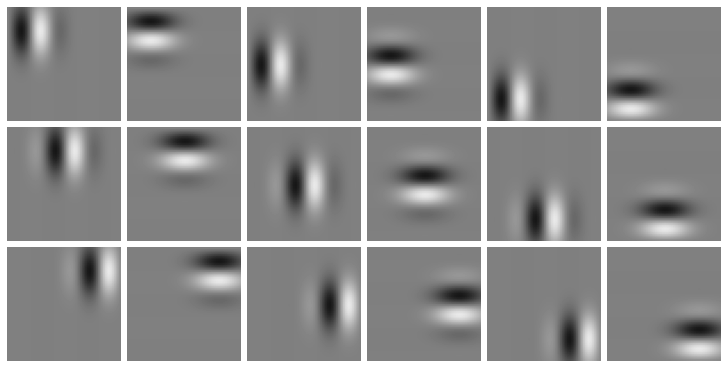

In [5]:
gabor_data = torch.load("/src/project/computed/gabors_overlapping.pt")
gabors = torch.tensor(gabor_data["gabors"].images()).float()
plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_data["gabors"].images()):
    plt.subplot(3, 6, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

In [7]:
gabor_data

{'gabors': <insilico_stimuli.stimuli.GaborSet at 0x7f15303f9070>,
 'params': {'canvas_size': [50, 50],
  'sizes': [30],
  'spatial_frequencies': [0.05],
  'contrasts': [1.0],
  'grey_levels': [0.0],
  'eccentricities': [0.0],
  'locations': [(10, 10),
   (10, 25),
   (10, 40),
   (25, 10),
   (25, 25),
   (25, 40),
   (40, 10),
   (40, 25),
   (40, 40)],
  'orientations': [3.141592653589793, 1.5707963267948966],
  'phases': [1.5707963267948966],
  'relative_sf': False}}

In [6]:
def sample_posterior(stimulus):
    z_dim = 18
    Lambda = torch.ones(z_dim)
    sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
        x = pm.Normal("stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimulus)
        trace = pm.sample(1_000, return_inferencedata=False)
    return trace

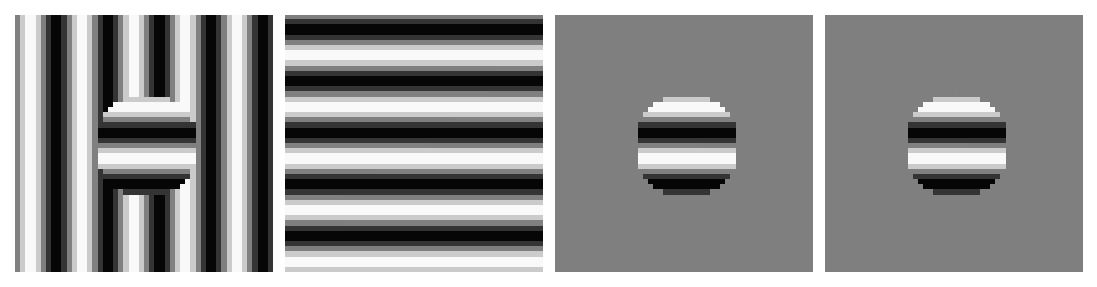

In [42]:
center_surround_params = {
    "canvas_size": [50, 50],
    "spatial_frequencies_center": [1/10],
    "spatial_frequencies_surround": [1/10],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [10/50],
    "sizes_surround": [10/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1, 0],
}
center_surround = CenterSurround(**center_surround_params)
center_surround_images = center_surround.images()

fig, axs = plt.subplots(nrows=1, ncols=4, dpi=150)
for i, ax in enumerate(axs.ravel()):
    ax.imshow(center_surround_images[i], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')


In [14]:
incongruent_surround, congruent_surround, circle_cut_center, _ = center_surround_images

In [15]:
trace_circle_cut_center = sample_posterior(torch.tensor(circle_cut_center))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


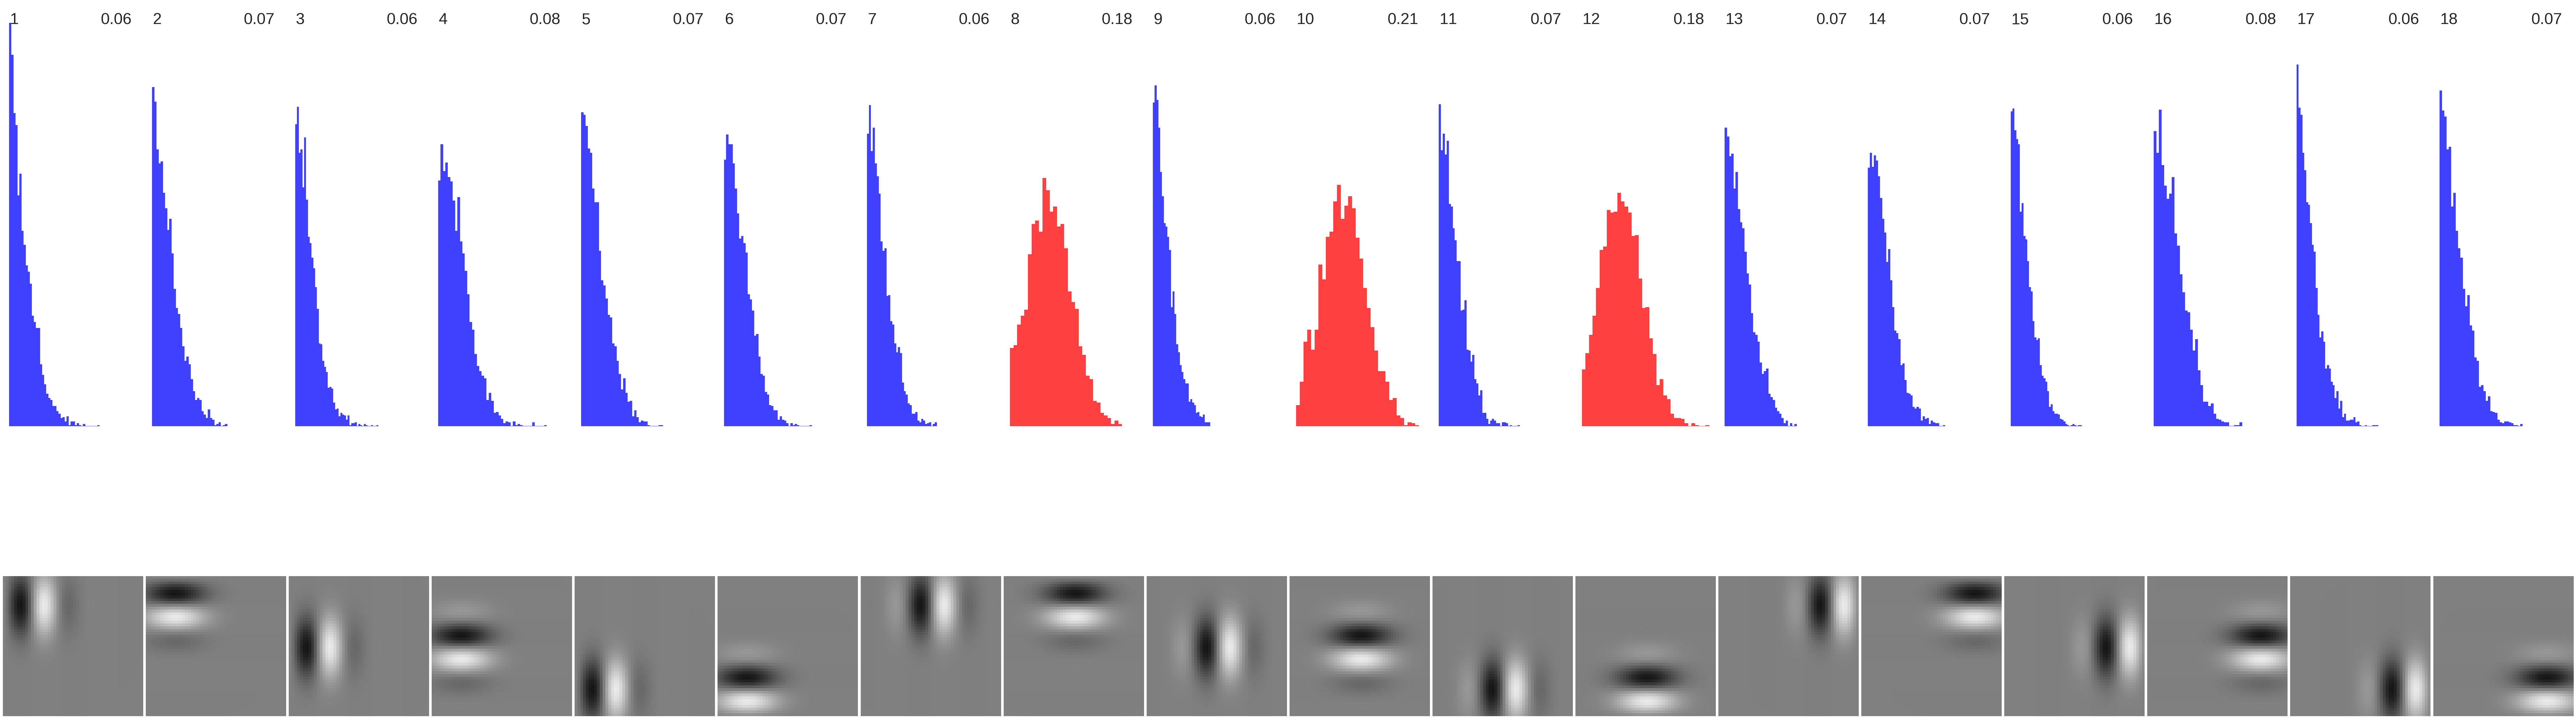

In [40]:
plot_posterior_samples(trace_circle_cut_center, gabors)

In [43]:
trace_circle_congruent = sample_posterior(torch.tensor(congruent_surround))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.


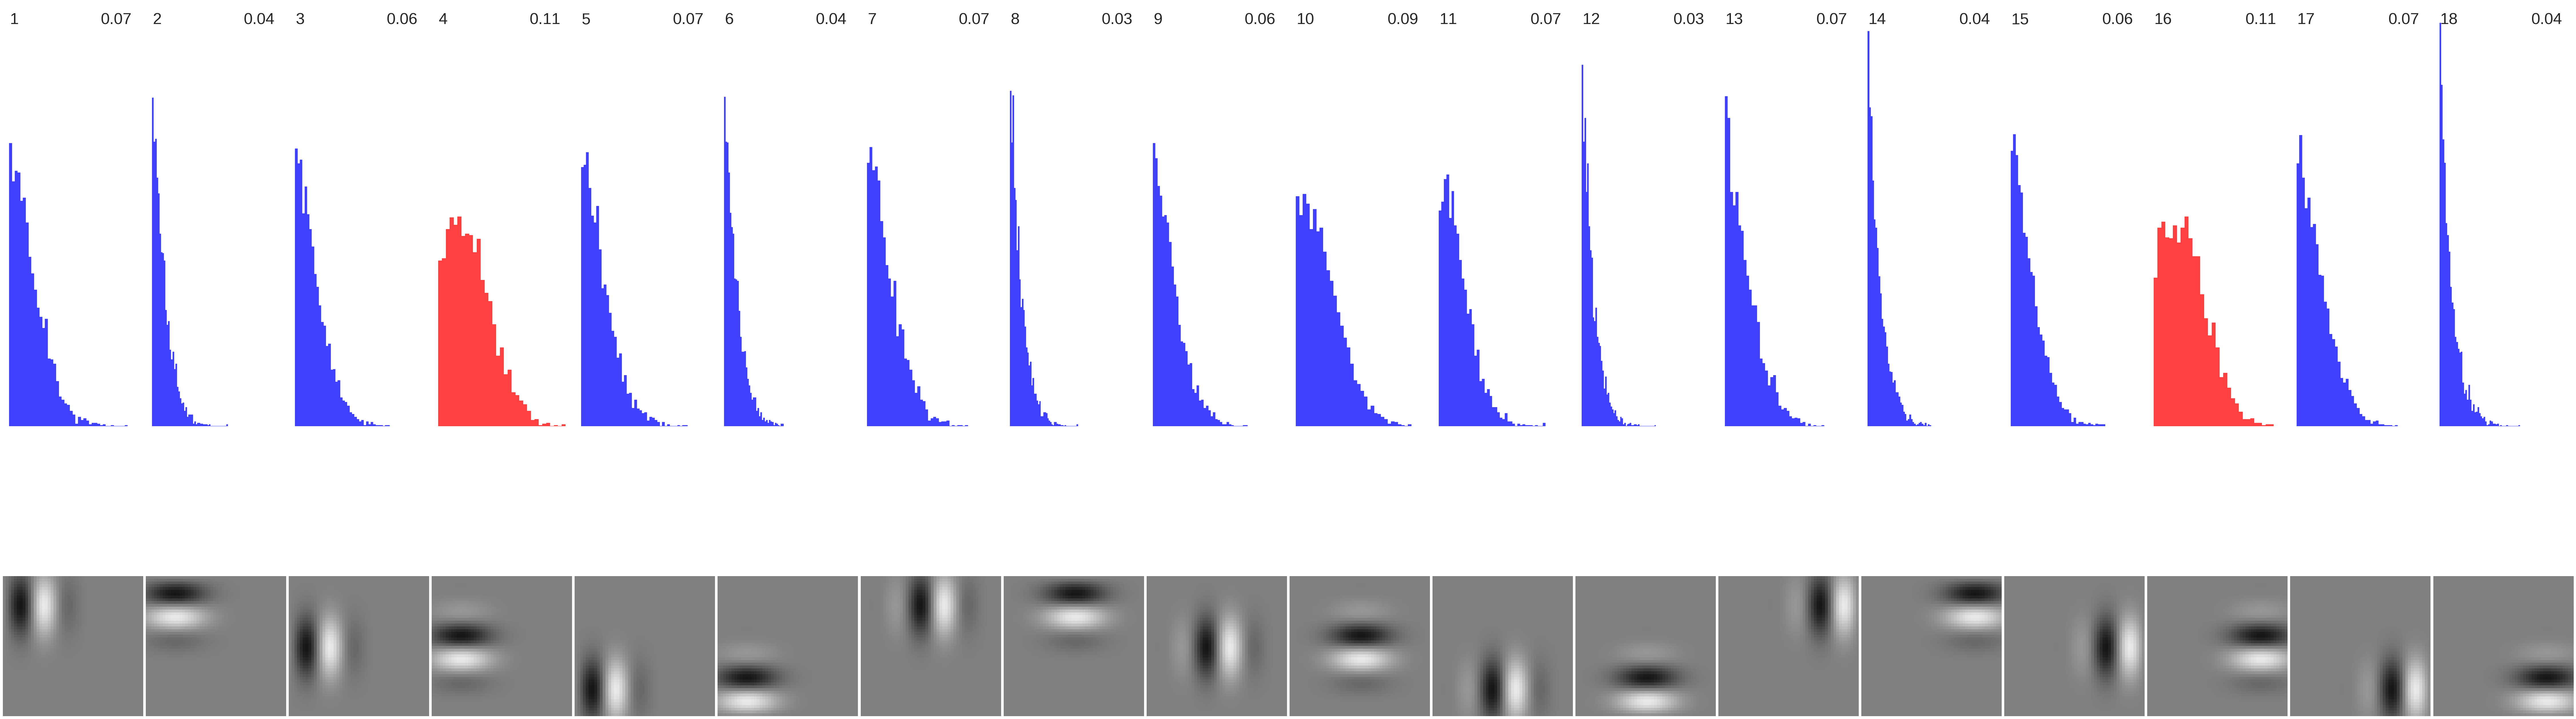

In [45]:
plot_posterior_samples(trace_circle_congruent, gabors)